In [1]:
# Financial Inclusion in Côte d'Ivoire — WAEMU Zone Analysis
# Author: Hamed Diomandé
# Data source: World Bank Global Findex 2021

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup — clean, professional
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# Custom color palette — warm, editorial
COLORS = {
    'primary': '#E67E22',
    'secondary': '#2C3E50',
    'accent': '#C0392B',
    'light': '#F39C12'
}

In [ ]:
# Load Global Findex 2021 country-level data
df = pd.read_excel(
    '../data/globalfindex-database-2021.xlsx',
    sheet_name='Data'
)

# Quick inspection
df.info()
df.head()

INFO: (642, 1232)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Columns: 1232 entries, countrynewwb to fin5_2017_d_12
dtypes: float64(2), object(1230)
memory usage: 6.0+ MB


,countrynewwb,codewb,pop_adult,year,regionwb21_hi,incomegroupwb21,account_t_d,fin1_t_d,fin1_1ab,fin1_1a,...,fin5_2017_d_3,fin5_2017_d_4,fin5_2017_d_5,fin5_2017_d_6,fin5_2017_d_7,fin5_2017_d_8,fin5_2017_d_9,fin5_2017_d_10,fin5_2017_d_11,fin5_2017_d_12
0,NaN,NaN,NaN,NaN,NaN,NaN,Account (% age 15+),Financial institution account (% age 15+),First financial institution account ever was o...,First financial institution account ever was o...,...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...,Used a mobile phone or the internet to access ...
1,Afghanistan,AFG,15124473.0,2011.0,South Asia,Low income,0.09005,0.09005,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,17300802.0,2014.0,South Asia,Low income,0.09961,0.09961,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,19718214.0,2017.0,South Asia,Low income,0.148933,0.145471,NaN,NaN,...,0,0.01469,0.003958,0.02265,0.003607,0.01282,NaN,NaN,0.000548,0.017173
4,Afghanistan,AFG,22647496.0,2021.0,South Asia,Low income,0.096538,0.096538,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# WAEMU (UEMOA) member states
waemu_countries = [
    "Cote d'Ivoire", "Senegal", "Mali", "Burkina Faso",
    "Benin", "Togo", "Niger", "Guinea"
]

# Filter dataset
waemu_df = df[df['countrynewwb'].isin(waemu_countries)]

print(f"WAEMU records: {len(waemu_df)}")

waemu_df['countrynewwb'].value_counts()

WAEMU records: 30


countrynewwb
Benin            4
Burkina Faso     4
Guinea           4
Mali             4
Senegal          4
Togo             4
Cote d'Ivoire    3
Niger            3
Name: count, dtype: int64

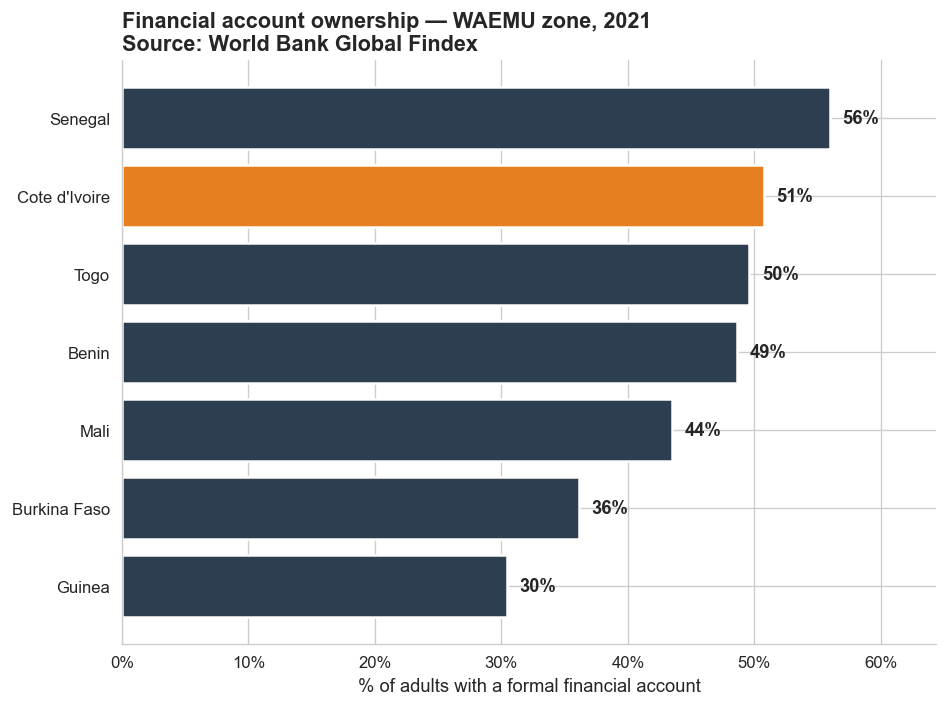

In [38]:
#Indicator: Account ownership  in 2021
from matplotlib.ticker import PercentFormatter
account_col = "account_t_d" 

waemu_2021 = waemu_df[waemu_df['year'] == 2021].copy()
waemu_2021 = waemu_2021.sort_values(account_col, ascending=True)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 6))
colors = [COLORS['primary'] if c == "Cote d'Ivoire" else COLORS['secondary']
          for c in waemu_2021['countrynewwb']]

bars = ax.barh(waemu_2021['countrynewwb'], waemu_2021[account_col],
                color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, waemu_2021[account_col]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('% of adults with a formal financial account', fontsize=11)
ax.set_title('Financial account ownership — WAEMU zone, 2021\nSource: World Bank Global Findex',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, max(waemu_2021[account_col]) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../output/01_waemu_comparison.png', bbox_inches='tight')
plt.show()

